In [45]:
import sys
import os
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


In [33]:
def read_json(path):
    """ Read a json file from the given path."""
    with open(path, 'r') as f:
        data = json.load(f)
    return data

def write_json(data, path):
    """ Write a json file to the given path."""
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))

    with open(path, 'w', encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)


In [35]:
path_to_dataset = "/Users/sefika/phd_projects/tgdk-paper/data/fire/data/fire_types.json"

In [37]:
fire_dataset_types = read_json(path_to_dataset)

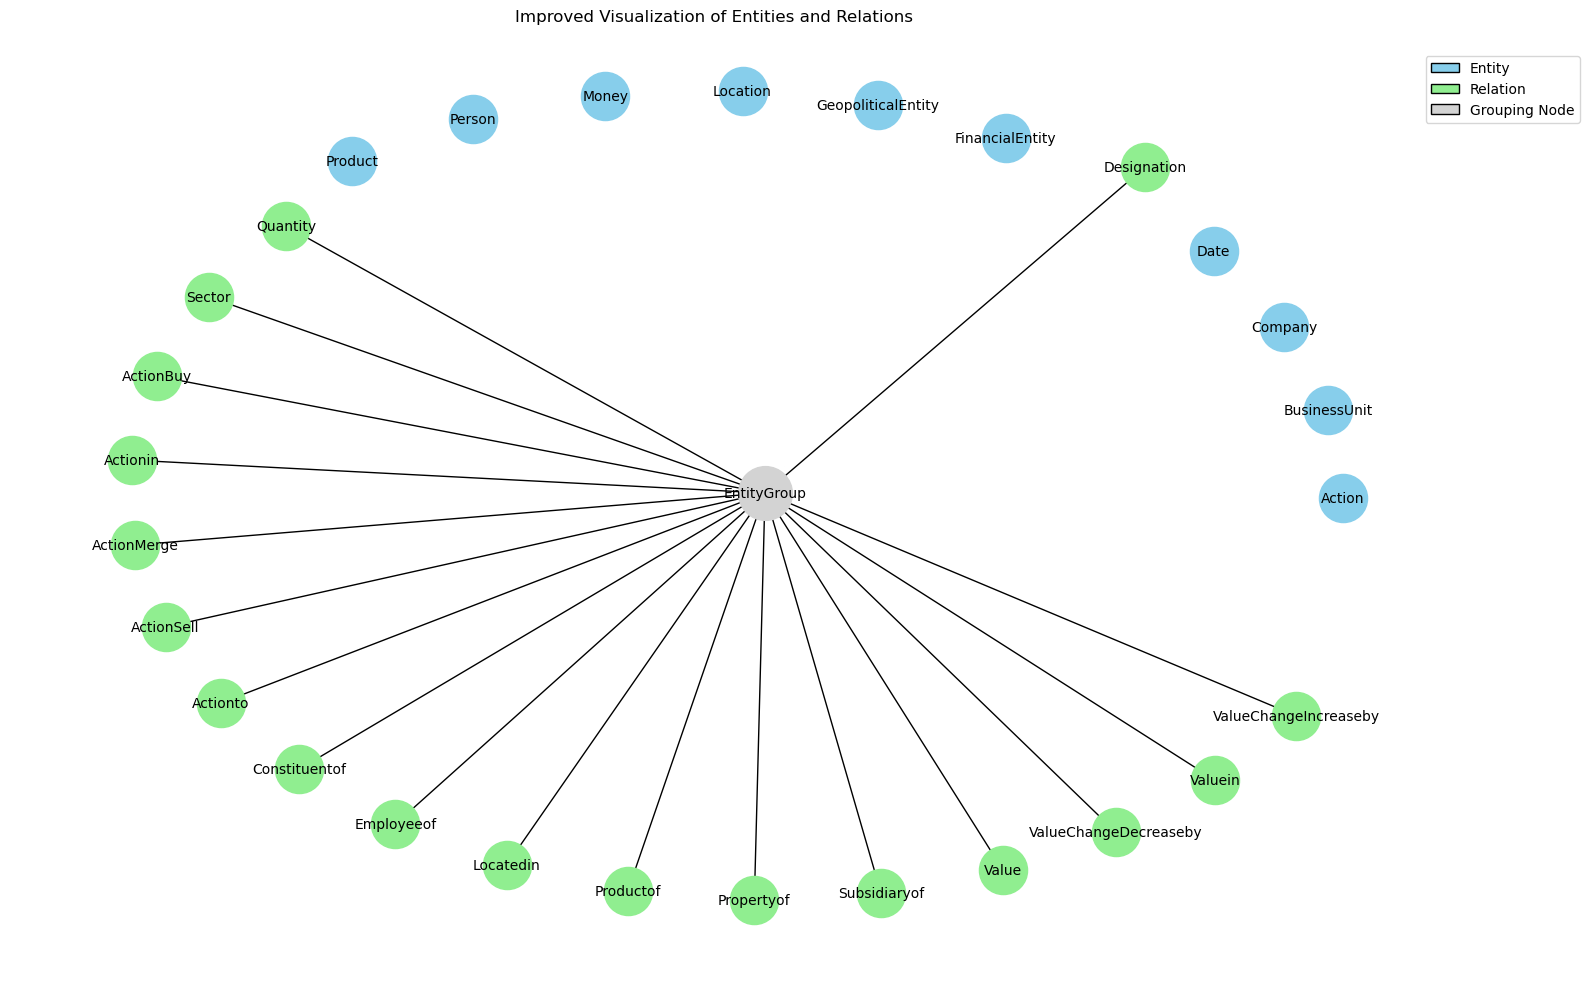

In [39]:


# Data as before (omitted for brevity)
data = fire_dataset_types
# Create graph
G = nx.DiGraph()

# Add nodes
for entity in data['entities']:
    G.add_node(entity, node_type='entity')
for relation in data['relations']:
    G.add_node(relation, node_type='relation')
G.add_node("EntityGroup", node_type="group")
for relation in data['relations']:
    G.add_edge("EntityGroup", relation)

# Choose a better layout for spacing
pos = nx.kamada_kawai_layout(G)

# Separate by type
entity_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'entity']
relation_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'relation']
group_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'group']

# Increase figure size
plt.figure(figsize=(16, 10))

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=entity_nodes, node_color='skyblue', node_size=1200)
nx.draw_networkx_nodes(G, pos, nodelist=relation_nodes, node_color='lightgreen', node_size=1200)
nx.draw_networkx_nodes(G, pos, nodelist=group_nodes, node_color='lightgray', node_size=1500)

# Draw edges
nx.draw_networkx_edges(G, pos, arrows=True)

# Draw labels with larger font
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

# Custom legend
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='black', label='Entity'),
    Patch(facecolor='lightgreen', edgecolor='black', label='Relation'),
    Patch(facecolor='lightgray', edgecolor='black', label='Grouping Node')
]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

# Display
plt.title("Improved Visualization of Entities and Relations", pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


In [51]:
# Create DataFrames
entities_df = pd.DataFrame.from_dict(data['entities'], orient='index')
entities_df['type'] = 'Entity'

relations_df = pd.DataFrame.from_dict(data['relations'], orient='index')
relations_df['type'] = 'Relation'

# Combine and show
entities_df


,short,verbose,type
Action,Action,Action,Entity
BusinessUnit,BusinessUnit,BusinessUnit,Entity
Company,Company,Company,Entity
Date,Date,Date,Entity
Designation,Designation,Designation,Entity
FinancialEntity,FinancialEntity,FinancialEntity,Entity
GeopoliticalEntity,GeopoliticalEntity,GeopoliticalEntity,Entity
Location,Location,Location,Entity
Money,Money,Money,Entity
Person,Person,Person,Entity


In [53]:
relations_df

,short,verbose,symmetric,type
ActionBuy,ActionBuy,ActionBuy,False,Relation
Actionin,Actionin,Actionin,False,Relation
ActionMerge,ActionMerge,ActionMerge,True,Relation
ActionSell,ActionSell,ActionSell,False,Relation
Actionto,Actionto,Actionto,False,Relation
Constituentof,Constituentof,Constituentof,False,Relation
Designation,Designation,Designation,False,Relation
Employeeof,Employeeof,Employeeof,False,Relation
Locatedin,Locatedin,Locatedin,False,Relation
Productof,Productof,Productof,False,Relation
